In [2]:
from sklearn.linear_model import Ridge , LogisticRegression
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.feature_extraction.text import CountVectorizer , TfidfVectorizer
import pandas as pd


mercari_df= pd.read_csv('../mercari_train.tsv',sep='\t')
print(mercari_df.shape)

(1482535, 8)


In [3]:
mercari_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1482535 entries, 0 to 1482534
Data columns (total 8 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   train_id           1482535 non-null  int64  
 1   name               1482535 non-null  str    
 2   item_condition_id  1482535 non-null  int64  
 3   category_name      1476208 non-null  str    
 4   brand_name         849853 non-null   str    
 5   price              1482535 non-null  float64
 6   shipping           1482535 non-null  int64  
 7   item_description   1482529 non-null  str    
dtypes: float64(1), int64(3), str(4)
memory usage: 90.5 MB


In [ ]:
mercari_df.sum()

Text(0, 0.5, 'Count')

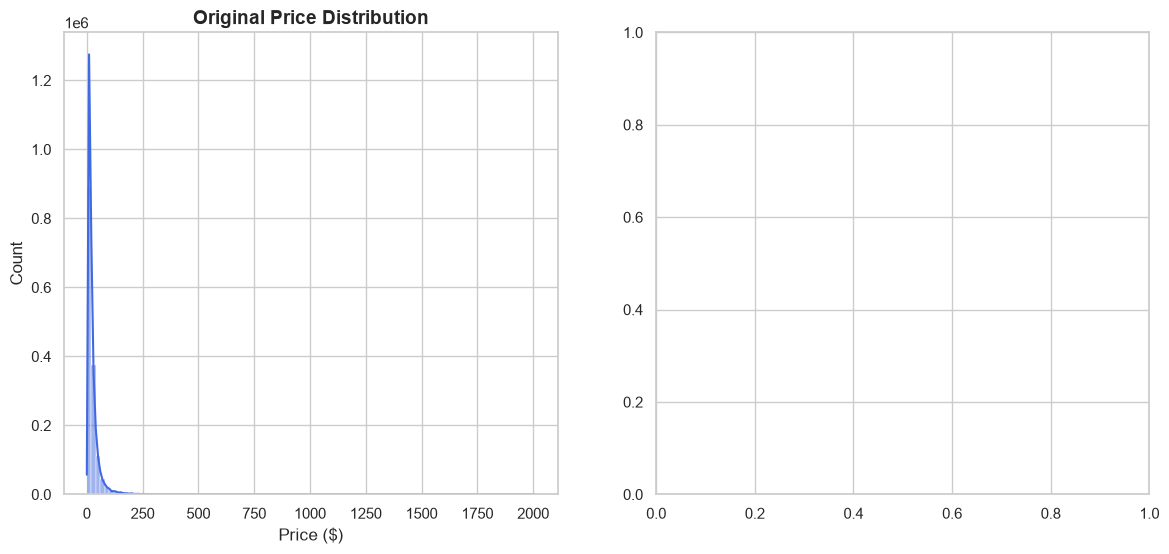

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. 시각화 스타일 및 그래프 크기 설정
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(figsize=(14, 6), nrows=1, ncols=2)

# 2. 왼쪽 그래프: 원본 가격 분포 (Original Price Distribution)
# 데이터가 너무 크고 우측 꼬리가 길기 때문에 bins를 넓게 채우고 x축 범위를 제한하여 가독성을 높입니다.
sns.histplot(
    mercari_df["price"], bins=100, kde=True, ax=axes[0], color="royalblue"
)
axes[0].set_title("Original Price Distribution", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Price ($)", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)

================================================================================
No.  Column Name        Non-Null Count   Dtype    데이터 속성 및 분석적 의미
================================================================================
 0   train_id           1,482,535        int64    연속형 식별자 (학습 제외 대상 변수)
 1   name               1,482,535        object   비정형 단문 텍스트 (Count 기반 벡터화 필요)
 2   item_condition_id  1,482,535        int64    순서형 범주형 (1~5 정수, 인코딩 필요)
 3   category_name      1,476,208        object   계층형 명목 범주형 (슬래시 분할 및 인코딩 필요)
 4   brand_name         849,853          object   고차원 명목 범주형 (대량 결측치 존재, 정제 필요)
 5   price              1,482,535        float64  연속형 수치 데이터 (최종 종속 변수 y, 로그화 필요)
 6   shipping           1,482,535        int64    이진 범주형 (0 또는 1, 인코딩 필요)
 7   item_description   1,482,529        object   비정형 장문 텍스트 (TF-IDF 기반 벡터화 필요)
================================================================================